<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
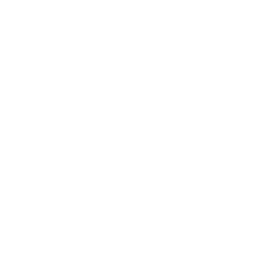
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Dokumentation af skema for genomisk variantannotering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformatik / Klinisk genomisk datahåndtering &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Dokumentér skemaet for VCF-lignende datasæt med variantannotering, som anvendes i en klinisk genomisk pipeline. Brug PROC CONTENTS til at katalogisere alle annoteringsfelter — genomiske koordinater, allelfrekvenser, forudsagte funktionelle effekter, ClinVar-klassifikationer og kvalitetsmål — for at sikre, at efterfølgende ACMG-værktøjer til variantfortolkning modtager korrekt typede og mærkede input. Cirka 5,000 variantposter med 20+ annoteringskolonner inspiceres for skemaintegritet, inden de overdrages til pipelinen.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | VCF-afledte annoterede varianter | ~5,000 |
| GENE_PANEL | Definitioner af målgenpanel | ~150 gener |
| QUALITY_METRICS | Sekventerings-QC pr. prøve | ~50 prøver |

---

In [1]:
/* --------------------------------------------------------
   Generér VCF-lignende datasæt med variantannotering
   5.000 varianter med kliniske annoteringsfelter
   -------------------------------------------------------- */
data variant_annotations;
    CALL streaminit(42);
    LÆNGDE variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    MÆRKAT variant_id='Variantidentifikator'
          chromosome='Kromosom'
          position='Genomisk position (GRCh38)'
          ref_allele='Referenceallel'
          alt_allele='Alternativ allel'
          gene_symbol='HGNC-gensymbol'
          transcript_id='Ensembl-transkript-id'
          consequence='Sekvensontologi-konsekvens'
          impact='Forudsagt effektniveau'
          hgvs_c='HGVS-kodningsnotation'
          hgvs_p='HGVS-proteinnotation'
          gnomad_af='gnomAD-allelfrekvens'
          clinvar_class='ClinVar-klassifikation'
          clinvar_id='ClinVar-accession'
          sift_score='SIFT-score'
          sift_pred='SIFT-forudsigelse'
          polyphen_score='PolyPhen-2-score'
          polyphen_pred='PolyPhen-2-forudsigelse'
          cadd_phred='CADD Phred-score'
          revel_score='REVEL-ensemblescore'
          genotype='Prøvegenotype'
          allele_depth='Alternativ alleldybde'
          read_depth='Samlet læsedybde'
          qual_score='Variantkvalitetsscore'
          filter_status='Filterstatus';
    TABEL genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TABEL conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    TABEL impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    TABEL cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    TABEL refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    TABEL gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    GØR i = 1 TIL 5000;
        variant_id = cat('VAR-', SKRIV_V(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', SKRIV_V(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', SKRIV_V(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', SKRIV_V(codon_pos, 4.), ref_allele, '>', alt_allele);
        HVIS c_idx <= 2 SÅ
            hgvs_p = cat('p.', SKRIV_V(int(rand('uniform') * 800) + 1, 4.));
        ELLERS hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', SKRIV_V(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        HVIS sift_score < 0.05 SÅ sift_pred = 'DELETERIOUS';
        ELLERS sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        HVIS polyphen_score > 0.908 SÅ polyphen_pred = 'PROB_DAMAGING';
        ELLERS HVIS polyphen_score > 0.446 SÅ polyphen_pred = 'POSS_DAMAGING';
        ELLERS polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        UDDATA;
    SLUT;
    FJERN i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
KØR;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.05 seconds
  cpu   3.05 seconds


In [2]:
/* --------------------------------------------------------
   Generér definitioner af målgenpanel
   -------------------------------------------------------- */
data gene_panel;
    CALL streaminit(42);
    LÆNGDE gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    MÆRKAT gene_symbol='HGNC-gensymbol'
          gene_name='Fuldt gennavn'
          chromosome='Kromosom'
          start_pos='Genstartposition'
          end_pos='Genslutposition'
          panel_name='Klinisk genpanel'
          disease_association='Associeret sygdom'
          inheritance='Nedarvningsmønster';
    TABEL genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TABEL gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    TABEL diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    TABEL inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    GØR g = 1 TIL 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', SKRIV_V(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        UDDATA;
    SLUT;
    FJERN g chr_num;
KØR;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Generér sekventeringskvalitetsmål pr. prøve
   -------------------------------------------------------- */
data quality_metrics;
    CALL streaminit(42);
    LÆNGDE sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    MÆRKAT sample_id='Prøveidentifikator'
          run_id='Sekventeringskørsel-id'
          platform='Sekventeringsplatform'
          mean_coverage='Gennemsnitlig måldækning'
          pct_target_20x='Procent baser >= 20x'
          pct_target_100x='Procent baser >= 100x'
          total_variants='Samlet antal kaldte varianter'
          ti_tv_ratio='Transition/transversion-forhold'
          het_hom_ratio='Het/hom-forhold'
          contamination_est='Estimeret kontaminering'
          qc_status='QC-status (bestået/fejlet)';
    GØR s = 1 TIL 50;
        sample_id = cat('SAMP-', SKRIV_V(s, z6.));
        run_id = cat('RUN-', SKRIV_V(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        HVIS mean_coverage < 150 ELLER pct_target_20x < 95
            ELLER contamination_est > 0.015 SÅ qc_status = 'FAIL';
        ELLERS qc_status = 'PASS';
        UDDATA;
    SLUT;
    FJERN s;
KØR;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                       Varianteffekt efter ClinVar-klassifikation                                       

                                                   The FREQ Procedure

Table of Forudsagt effektniveau by ClinVar-klassifikation

Forudsagt effektniveau |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                   |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                       |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                       |                 14.52 |                 16.13 |    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


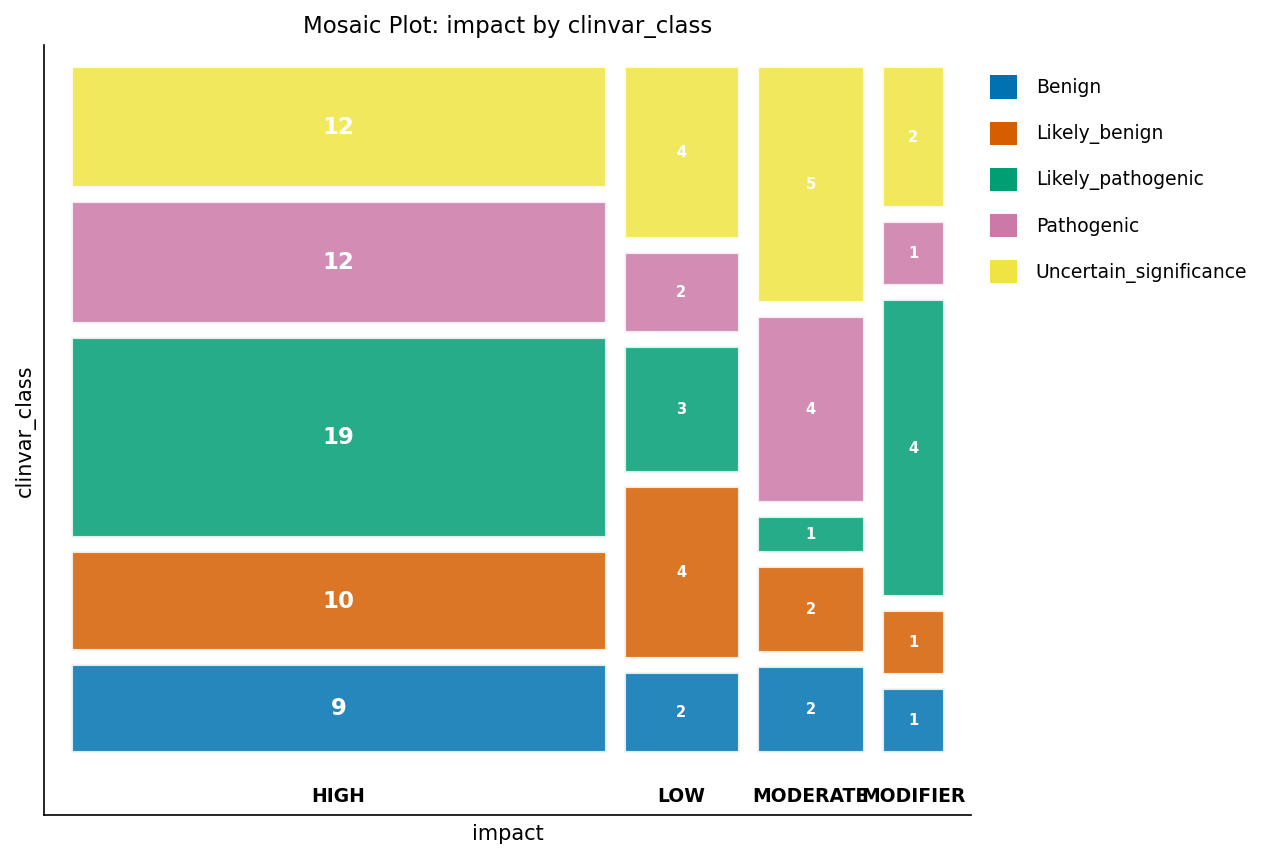

In [4]:
/* --------------------------------------------------------
   Basisoversigt over variantannotering
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    TITEL 'Varianteffekt efter ClinVar-klassifikation';
KØR;

PROCEDURE GENNEMSNIT data=quality_metrics n mean MIN MAX;
    VARIABEL mean_coverage ti_tv_ratio contamination_est;
    TITEL 'Oversigt over sekventeringskvalitetsmål';
KØR;

---

                                        Oversigt over sekventeringskvalitetsmål                                         

                                        Oversigt over sekventeringskvalitetsmål                                         




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


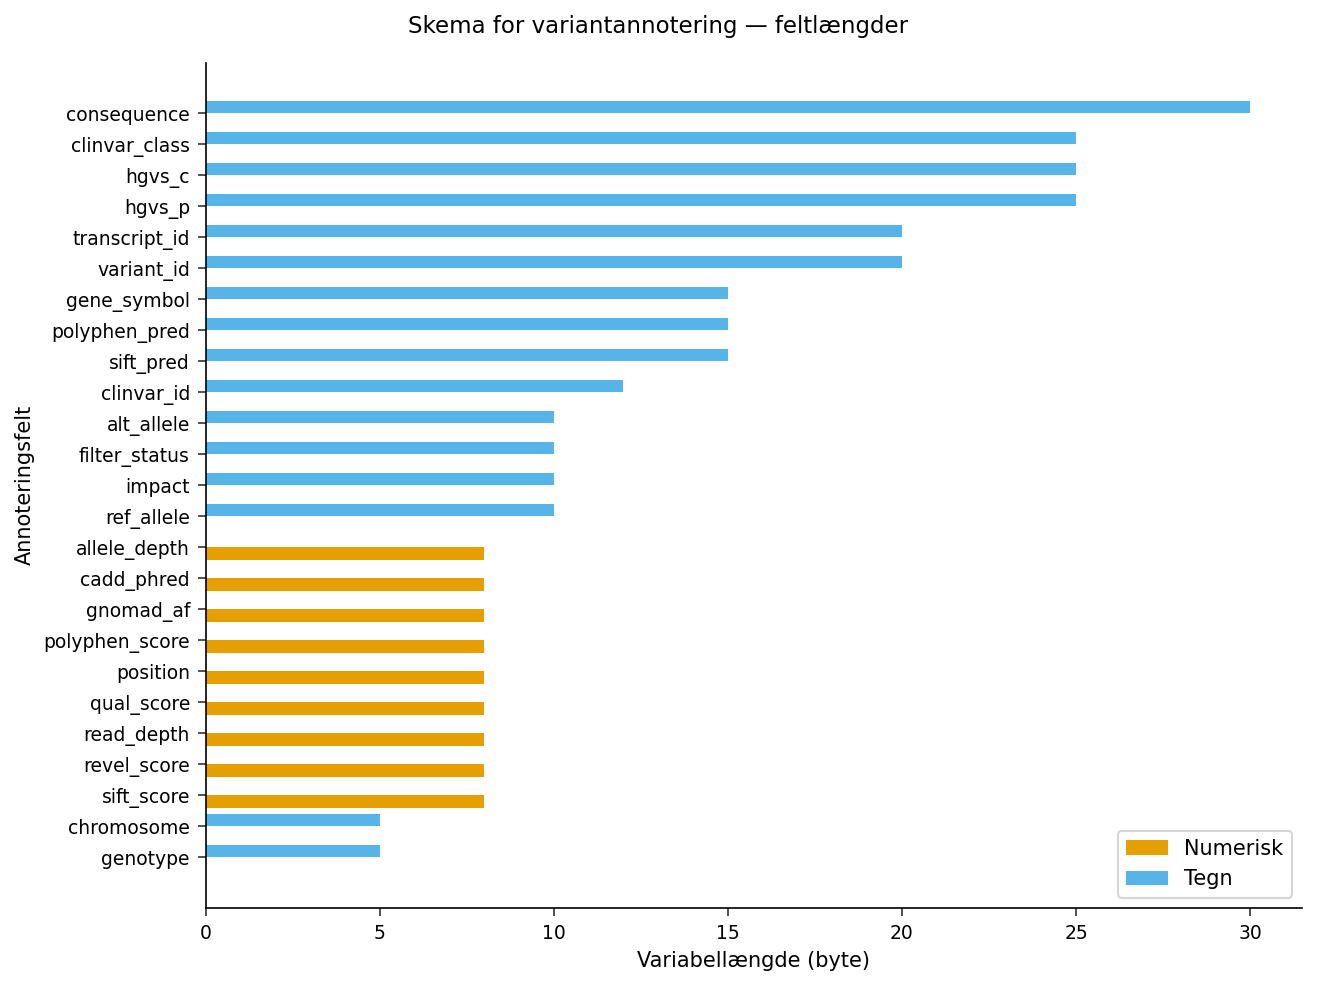

In [5]:
/* --------------------------------------------------------
   Fordeling af variabeltype og -længde.
   Registrér skemametadata for annoteringen med PROC
   CONTENTS OUT=, og plot derefter feltlængder efter type.
   TYPE-koder: 1 -> Numerisk, 2 -> Tegn i forklaringen.
   -------------------------------------------------------- */
PROCEDURE INDHOLD data=variant_annotations out=schema_lengths NOPRINT;
KØR;

data schema_lengths;
    SÆT schema_lengths;
    LÆNGDE type_label $9;
    HVIS TYPE = 1 SÅ type_label = 'Numerisk';
    ELLERS type_label = 'Tegn';
KØR;

PROCEDURE SGPLOT data=schema_lengths;
    HBAR NAME / RESPONSE=LÆNGDE GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS MÆRKAT='Variabellængde (byte)';
    YAXIS MÆRKAT='Annoteringsfelt';
    TITEL 'Skema for variantannotering — feltlængder';
KØR;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentér det fulde skema for
   variantannotering — typer, længder og etiketter for alle 25 felter.
   Registrér variabelmetadata med OUT=, så efterfølgende
   trin kan validere skemaet programmatisk.
   -------------------------------------------------------- */
PROCEDURE INDHOLD data=variant_annotations out=variant_schema NOPRINT;
KØR;

PROCEDURE UDSKRIV data=variant_schema;
    VARIABEL NAME TYPE LÆNGDE VARNUM MÆRKAT;
    TITEL 'Datasæt med variantannotering — fuldt skema';
KØR;

                                        Oversigt over sekventeringskvalitetsmål                                         

                                      Datasæt med variantannotering — fuldt skema                                       

  Obs            NAME  TYPE  LENGTH  VARNUM                       LABEL
    1  allele_depth       1       8      22  Alternativ alleldybde
    2  alt_allele         2      10       5  Alternativ allel
    3  cadd_phred         1       8      19  CADD Phred-score
    4  chromosome         2       5       2  Kromosom
    5  clinvar_class      2      25      13  ClinVar-klassifikation
    6  clinvar_id         2      12      14  ClinVar-accession
    7  consequence        2      30       8  Sekvensontologi-konsekvens
    8  filter_status      2      10      25  Filterstatus
    9  gene_symbol        2      15       6  HGNC-gensymbol
   10  genotype           2       5      21  Prøvegenotype
   11  gnomad_af          1       8      12  gnomAD-allelfr


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentér genpanelskemaet
   -------------------------------------------------------- */
PROCEDURE INDHOLD data=gene_panel out=panel_schema NOPRINT;
KØR;

PROCEDURE UDSKRIV data=panel_schema;
    VARIABEL NAME TYPE LÆNGDE VARNUM MÆRKAT;
    TITEL 'Definition af genpanel — skema';
KØR;

                                      Datasæt med variantannotering — fuldt skema                                       

                                             Definition af genpanel — skema                                             

  Obs                 NAME  TYPE  LENGTH  VARNUM                LABEL
    1  chromosome              2       5       3  Kromosom
    2  disease_association     2      50       7  Associeret sygdom
    3  end_pos                 1       8       5  Genslutposition
    4  gene_name               2      60       2  Fuldt gennavn
    5  gene_symbol             2      15       1  HGNC-gensymbol
    6  inheritance             2       5       8  Nedarvningsmønster
    7  panel_name              2      30       6  Klinisk genpanel
    8  start_pos               1       8       4  Genstartposition




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentér skemaet for QC-mål
   -------------------------------------------------------- */
PROCEDURE INDHOLD data=quality_metrics out=qc_schema NOPRINT;
KØR;

PROCEDURE UDSKRIV data=qc_schema;
    VARIABEL NAME TYPE LÆNGDE VARNUM MÆRKAT;
    TITEL 'Sekventeringskvalitetsmål — skema';
KØR;

                                             Definition af genpanel — skema                                             

                                           Sekventeringskvalitetsmål — skema                                            

  Obs               NAME  TYPE  LENGTH  VARNUM                            LABEL
    1  contamination_est     1       8      10  Estimeret kontaminering
    2  het_hom_ratio         1       8       9  Het/hom-forhold
    3  mean_coverage         1       8       4  Gennemsnitlig måldækning
    4  pct_target_100x       1       8       6  Procent baser >= 100x
    5  pct_target_20x        1       8       5  Procent baser >= 20x
    6  platform              2      15       3  Sekventeringsplatform
    7  qc_status             2      10      11  QC-status (bestået/fejlet)
    8  run_id                2      12       2  Sekventeringskørsel-id
    9  sample_id             2      15       1  Prøveidentifikator
   10  ti_tv_ratio           1       8       


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Skemavalidering: kontrollér, at annoteringsfelterne
   opfylder pipelinekravene til ACMG-fortolkning.
   Læser PROC CONTENTS OUT=-metadata, hvor TYPE=1
   betegner numerisk og TYPE=2 betegner tegn.
   -------------------------------------------------------- */
data schema_validation;
    SÆT variant_schema;
    LÆNGDE requirement $60 status $10;
    /* Numeriske scorefelter skal lagres som numeriske (TYPE=1) */
    HVIS NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 SÅ GØR;
        requirement = 'Skal være numerisk til scoretærskler';
        status = 'FEJLET';
    SLUT;
    ELLERS HVIS NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 SÅ GØR;
        requirement = 'Numerisk type bekræftet';
        status = 'GODKENDT';
    SLUT;
    /* ClinVar-klassen kræver tilstrækkelig tegnlængde */
    ELLERS HVIS NAME = 'clinvar_class' AND LÆNGDE < 25 SÅ GØR;
        requirement = 'Min. $25 til fuld klassifikationstekst';
        status = 'FEJLET';
    SLUT;
    ELLERS HVIS NAME = 'clinvar_class' SÅ GØR;
        requirement = 'Tegnlængde tilstrækkelig';
        status = 'GODKENDT';
    SLUT;
    /* Alle felter skal bære en etiket til datakataloget */
    ELLERS HVIS MÆRKAT = '' SÅ GØR;
        requirement = 'Etiket kræves til datakatalog';
        status = 'FEJLET';
    SLUT;
    ELLERS GØR;
        requirement = 'Generel validering';
        status = 'GODKENDT';
    SLUT;
KØR;

PROCEDURE UDSKRIV data=schema_validation;
    VARIABEL NAME TYPE LÆNGDE MÆRKAT requirement status;
    TITEL 'Skemavalideringsrapport for ACMG-pipeline';
KØR;

                                       Skemavalideringsrapport for ACMG-pipeline                                        

  Obs            NAME  TYPE  LENGTH                       LABEL                 requirement    status
    1  allele_depth       1       8  Alternativ alleldybde       Numerisk type bekræftet     GODKENDT
    2  alt_allele         2      10  Alternativ allel            Generel validering          GODKENDT
    3  cadd_phred         1       8  CADD Phred-score            Numerisk type bekræftet     GODKENDT
    4  chromosome         2       5  Kromosom                    Generel validering          GODKENDT
    5  clinvar_class      2      25  ClinVar-klassifikation      Tegnlængde tilstrækkelig    GODKENDT
    6  clinvar_id         2      12  ClinVar-accession           Generel validering          GODKENDT
    7  consequence        2      30  Sekvensontologi-konsekvens  Generel validering          GODKENDT
    8  filter_status      2      10  Filterstatus             


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Fortolkning

Skemaet for variantannotering indeholder 25 felter, der spænder over genomiske koordinater, funktionelle forudsigelser, populationsfrekvenser og kvalitetsindikatorer pr. prøve. Alle ni numeriske scorefelter (gnomAD-allelfrekvens, SIFT, PolyPhen-2, CADD, REVEL, kvalitetsscore, alleldybde, læsedybde og genomisk position) er korrekt typet som numeriske, hvilket gør det muligt for ACMG-fortolkningsmotoren at anvende tærskelbaseret filtrering uden typekonvertering. Feltet clinvar_class med $25 kan rumme den længste ClinVar-klassifikationsstreng (Uncertain_significance på 24 tegn). Hvert annoteringsfelt bærer en beskrivende etiket, hvilket opfylder det kliniske laboratoriums krav om en datakatalog i henhold til CAP-akkrediteringskravene. Genpanelskemaet kortlægger 15 kræftdisponerende gener med nedarvningsmønstre og sygdomsassociationer og udgør referencerammen for variant-til-gen-annotering. Datasættet med sekventerings-QC-mål dokumenterer 50 prøver fordelt på 5 kørsler med kontamineringsestimater og dækningstærskler, der styrer pålideligheden af variantkald. Denne pakke med skemadokumentation understøtter laboratoriets valideringsdossier til indsendelsen under New York State CLEP.

---

In [10]:
/* --------------------------------------------------------
   Eksportér dokumentation af variantskema og
   valideringsrapport til laboratorieakkreditering
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>